## 1. Library importing

In [9]:
import sys
import time
import numpy as np
from numba import cuda
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

## 2. Reduce functions

In [2]:
@cuda.jit
def reduce_sum_kernel(data, partial):
    shared_memory = cuda.shared.array(256, dtype=np.float64)

    thread_id = cuda.threadIdx.x
    index = cuda.blockIdx.x * (cuda.blockDim.x * 2) + thread_id

    s = 0.0
    if index < data.size:
        s += data[index]
    if index + cuda.blockDim.x < data.size:
        s += data[index + cuda.blockDim.x]

    shared_memory[thread_id] = s
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
        if thread_id < stride:
            shared_memory[thread_id] += shared_memory[thread_id + stride]
        cuda.syncthreads()
        stride //= 2

    if thread_id == 0:
        partial[cuda.blockIdx.x] = shared_memory[0]


@cuda.jit
def final_reduce_kernel(data, out):
    shared_memory = cuda.shared.array(256, dtype=np.float64)

    thread_id = cuda.threadIdx.x
    s = 0.0
    if thread_id < data.size:
        s = data[thread_id]

    shared_memory[thread_id] = s
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
        if thread_id < stride:
            shared_memory[thread_id] += shared_memory[thread_id + stride]
        cuda.syncthreads()
        stride //= 29

    if thread_id == 0:
        out[0] = shared_memory[0]

## 3. Sum functions

In [3]:
def cpu_sum(data):
    s = 0.0
    for x in data:
        s += x
    return s


def gpu_sum(data):
    n = data.size
    threads = 256
    blocks = (n + threads * 2 - 1) // (threads * 2)

    device_inp = cuda.to_device(data)
    device_partial = cuda.device_array(blocks, dtype=np.float64)

    start = cuda.event(timing=True)
    end = cuda.event(timing=True)

    start.record()
    reduce_sum_kernel[blocks, threads](device_inp, device_partial)

    current = device_partial
    while current.size > 1:
        next_blocks = (current.size + threads * 2 - 1) // (threads * 2)
        device_next = cuda.device_array(next_blocks, dtype=np.float64)
        reduce_sum_kernel[next_blocks, threads](current, device_next)
        current = device_next

    device_result = cuda.device_array(1, dtype=np.float64)
    final_reduce_kernel[1, threads](current, device_result)
    end.record()
    end.synchronize()

    gpu_ms = cuda.event_elapsed_time(start, end)
    result = device_result.copy_to_host()[0]
    return result, gpu_ms


## 4. Calculation function

In [10]:
def compute(n=1000000):

    rng = np.random.default_rng(42)
    data = rng.random(n, dtype=np.float64)

    t0 = time.perf_counter()
    cpu_result = cpu_sum(data)
    cpu_ms = (time.perf_counter() - t0) * 1000.0

    gpu_result, gpu_ms = gpu_sum(data)
    diff = abs(cpu_result - gpu_result)
    speedup = cpu_ms / gpu_ms

    print(f"N = {n}")
    print(f"CPU: {cpu_ms:.3f} ms\t\tGPU: {gpu_ms:.3f} ms")
    print(f"Difference = {diff:.10e}")
    #print(f"Speedup = {speedup:.3f}x")

    temp_result = {
        'N': n,
        'CPU_ms': cpu_ms,
        'GPU_ms': gpu_ms,
        'Speedup': speedup,
        'Difference': diff
    }
    
    return temp_result

def experiment(params):
    
    print("Experiment is running...")
    
    results = []
    
    for n in params:
        print('-'*40)
        results.append(compute(n))

    print("\nExperiments are completed")
    results = pd.DataFrame(results)

    return results
        

## 5. Starting experiment

In [11]:
params = [1000, 5000, 10000, 50000, 100000, 200000, 500000, 1000000]

results = experiment(params)
results['Diff_OK'] = results.Difference <1e-4

Experiment is running...
----------------------------------------
N = 1000
CPU: 0.127 ms		GPU: 0.569 ms
Difference = 6.8212102633e-13
----------------------------------------
N = 5000
CPU: 0.627 ms		GPU: 0.266 ms
Difference = 4.0927261580e-12
----------------------------------------
N = 10000
CPU: 1.194 ms		GPU: 0.317 ms
Difference = 4.5474735089e-12
----------------------------------------
N = 50000
CPU: 5.782 ms		GPU: 0.249 ms
Difference = 4.0017766878e-11
----------------------------------------
N = 100000
CPU: 9.271 ms		GPU: 0.279 ms
Difference = 6.9849193096e-10
----------------------------------------
N = 200000
CPU: 19.089 ms		GPU: 0.269 ms
Difference = 1.1204974726e-09
----------------------------------------
N = 500000
CPU: 46.474 ms		GPU: 0.375 ms
Difference = 8.0035533756e-09
----------------------------------------
N = 1000000
CPU: 98.049 ms		GPU: 0.367 ms
Difference = 2.2118911147e-08

Experiments are completed


## 6. Results

In [12]:
results.head(10)

,N,CPU_ms,GPU_ms,Speedup,Difference,Diff_OK
0,1000,0.127048,0.569376,0.223136,6.821210e-13,True
1,5000,0.627115,0.265984,2.357717,4.092726e-12,True
2,10000,1.194053,0.316800,3.769107,4.547474e-12,True
3,50000,5.781623,0.248864,23.232059,4.001777e-11,True
4,100000,9.270861,0.278624,33.273735,6.984919e-10,True
5,200000,19.088822,0.268928,70.981165,1.120497e-09,True
6,500000,46.474174,0.375424,123.791165,8.003553e-09,True
7,1000000,98.048621,0.367168,267.040206,2.211891e-08,True


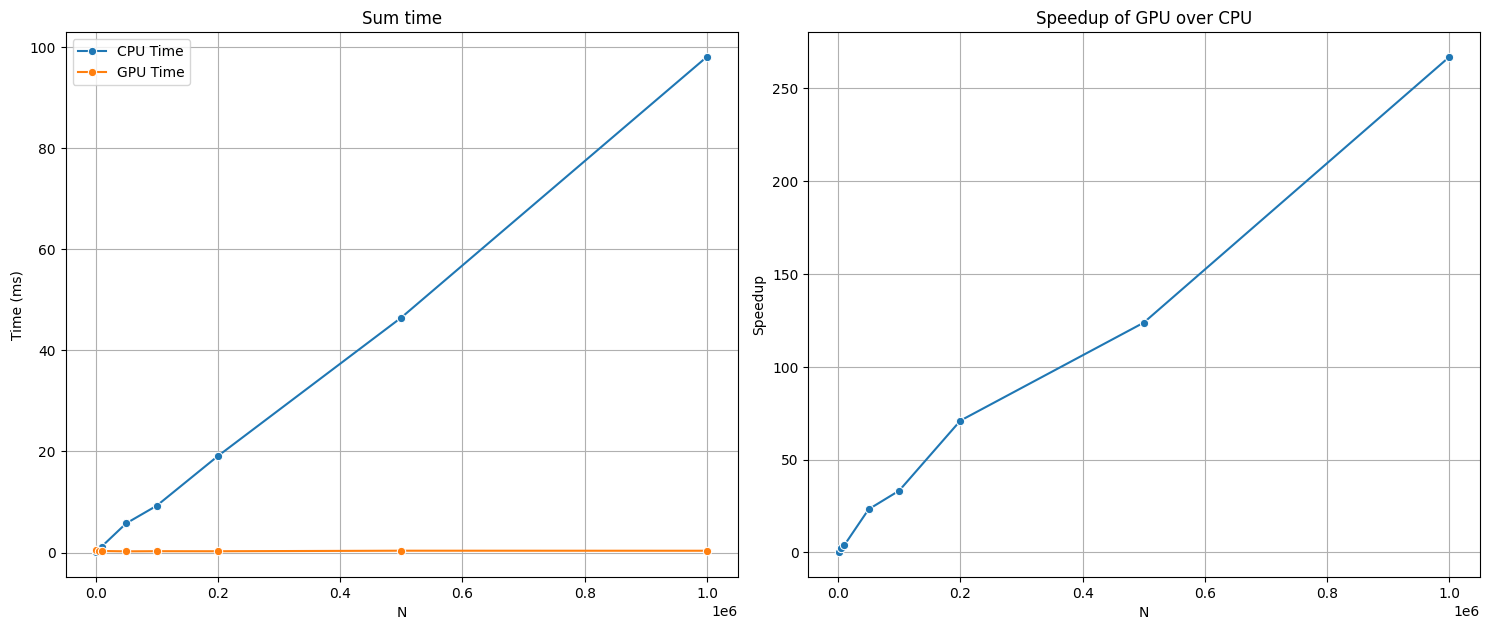

In [16]:
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
sns.lineplot(x='N', y='CPU_ms', data=results, label='CPU Time', marker='o', ax=ax0)
sns.lineplot(x='N', y='GPU_ms', data=results, label='GPU Time', marker='o', ax=ax0)
ax0.set_xlabel('N')
ax0.set_ylabel('Time (ms)')
ax0.set_title('Sum time')
ax0.legend()
ax0.grid(True)

ax1 = fig.add_subplot(gs[0, 1])
sns.lineplot(x='N', y='Speedup', data=results, marker='o', ax=ax1)
ax1.set_xlabel('N')
ax1.set_ylabel('Speedup')
ax1.set_title('Speedup of GPU over CPU')
ax1.grid(True)

plt.tight_layout()
plt.show()